# 04 - Transfer Learning VGG16

Uso VGG16 preentrenada en ImageNet como base para clasificar las enfermedades.
El entrenamiento tiene dos fases:
- Fase 1: congelo toda la base y solo entreno la cabeza nueva (feature extraction)
- Fase 2: descongelo el ultimo bloque de VGG16 y afino con learning rate muy bajo (fine-tuning)

> **Nota:** si `vgg16_best.keras` ya esta en la carpeta de Drive, gdown lo descarga al inicio. Hay una celda opcional antes de la fase 1 que carga el modelo directamente para saltarse el entrenamiento.

In [ ]:
!pip install kagglehub gdown scikit-learn seaborn --quiet

In [2]:
import os

WORK_PATH = '/content/plantvillage'
os.makedirs(WORK_PATH, exist_ok=True)

In [3]:
import gdown
gdown.download_folder(
    'https://drive.google.com/drive/folders/1OCOyDSR9C3TCzLthsMxJCmy6wcjM3pxs',
    output=WORK_PATH,
    quiet=True
)

Retrieving folder contents


Processing file 1pTL1_b2nt4sEU2ZjJlUOEHe_ItqIicBs baseline_best.keras
Processing file 1KEXE2EKbLq2FX2MnRvLdtw7GLt8_H0bl class_weight.json
Processing file 1TnugSrq4R66xPa__PM8AtVdBzgA5TtnF dataset_info.json
Processing file 15SC0uFwvRBeilOyAb4ninCvwOYtP59n9 resultados_baseline.json


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1pTL1_b2nt4sEU2ZjJlUOEHe_ItqIicBs
To: /content/plantvillage/baseline_best.keras
100%|██████████| 9.41M/9.41M [00:00<00:00, 62.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KEXE2EKbLq2FX2MnRvLdtw7GLt8_H0bl
To: /content/plantvillage/class_weight.json
100%|██████████| 1.05k/1.05k [00:00<00:00, 4.18MB/s]
Downloading...
From: https://drive.google.com/uc?id=1TnugSrq4R66xPa__PM8AtVdBzgA5TtnF
To: /content/plantvillage/dataset_info.json
100%|██████████| 2.87k/2.87k [00:00<00:00, 11.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=15SC0uFwvRBeilOyAb4ninCvwOYtP59n9
To: /content/plantvillage/resultados_baseline.json
100%|██████████| 98.0/98.0 [00:00<00:00, 446kB/s]
Download completed


['/content/plantvillage/baseline_best.keras',
 '/content/plantvillage/class_weight.json',
 '/content/plantvillage/dataset_info.json',
 '/content/plantvillage/resultados_baseline.json']

In [ ]:
import tensorflow as tf
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import classification_report, confusion_matrix

print('tensorflow:', tf.__version__)
print('gpu disponible:', tf.config.list_physical_devices('GPU'))

tf.random.set_seed(42)
np.random.seed(42)

## Parametros y datos

Las imagenes entran en [0, 255]. El preprocesado de VGG16 y el augmentation los puse dentro del modelo.

In [5]:
with open(f'{WORK_PATH}/dataset_info.json') as f:
    ds_info = json.load(f)
with open(f'{WORK_PATH}/class_weight.json') as f:
    class_weight = {int(k): v for k, v in json.load(f).items()}

NUM_CLASSES = ds_info['num_classes']
CLASS_NAMES = ds_info['class_names']
IMG_SIZE    = 224
BATCH_SIZE  = 32
AUTOTUNE    = tf.data.AUTOTUNE

print('clases:', NUM_CLASSES)
print('tamano imagen:', IMG_SIZE)

clases: 38
tamano imagen: 224


In [ ]:
_path = kagglehub.dataset_download('abdallahalidev/plantvillage-dataset')
DATA_DIR = _path + '/plantvillage dataset/color'

full_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(256, 256),
    batch_size=None,
    shuffle=True,
    seed=42,
    label_mode='int'
)

TOTAL   = int(full_ds.cardinality().numpy())
n_train = int(0.70 * TOTAL)
n_val   = int(0.15 * TOTAL)

ds_train_raw = full_ds.take(n_train)
ds_val_raw   = full_ds.skip(n_train).take(n_val)
ds_test_raw  = full_ds.skip(n_train + n_val)

# imagenes en [0, 255]; el preprocesado especifico va dentro del modelo
def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, label

ds_train = (
    ds_train_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .shuffle(2000, seed=42)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
ds_val = (
    ds_val_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
ds_test = (
    ds_test_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print('pipeline listo')

## Construccion del modelo

VGG16 con pesos de ImageNet sin la cabeza original. Antes de la base pongo el augmentation y el preprocesado de VGG16. Uso float32 explicito en la salida para evitar problemas de precision.

In [7]:
base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
# congelo la base para la fase 1
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# augmentation en [0,255]
x = tf.keras.layers.RandomFlip('horizontal_and_vertical')(inputs)
x = tf.keras.layers.RandomRotation(0.2)(x)
x = tf.keras.layers.RandomZoom(0.2)(x)
x = tf.keras.layers.RandomBrightness(0.2, value_range=(0, 255))(x)
x = tf.keras.layers.RandomContrast(0.2)(x)

# preprocesado de VGG16
x = tf.keras.layers.Lambda(
    tf.keras.applications.vgg16.preprocess_input,
    name='vgg16_preprocess'
)(x)

x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

model = tf.keras.Model(inputs, outputs, name='vgg16_transfer')

total      = model.count_params()
entrenables = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'parametros totales:      {total:,}')
print(f'parametros entrenables:  {entrenables:,}')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
parametros totales:      14,855,782
parametros entrenables:  141,094


In [ ]:
model.summary()

In [ ]:
# si vgg16_best.keras ya fue descargado por gdown al inicio, podemos cargar el modelo
# y saltarnos las celdas de fase 1, fase 2 y curvas
# cambia REENTRENAR = True si queres volver a entrenar desde cero
REENTRENAR = False

ruta_modelo = f'{WORK_PATH}/vgg16_best.keras'

if os.path.exists(ruta_modelo) and not REENTRENAR:
    model = tf.keras.models.load_model(
        ruta_modelo,
        custom_objects={'preprocess_input': tf.keras.applications.vgg16.preprocess_input}
    )
    print('modelo cargado desde Drive')
    print('saltate las celdas de fase 1, fase 2 y curvas')
    print('ejecuta directamente la celda de evaluacion en test')
else:
    print('modelo no encontrado o REENTRENAR=True, ejecuta las celdas de entrenamiento')

## Fase 1 - feature extraction

Con la base congelada solo se actualizan los pesos de la cabeza nueva. Uso un learning rate alto porque los pesos de VGG16 no van a cambiar.

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fase1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=4, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=f'{WORK_PATH}/vgg16_fase1_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

print('fase 1: feature extraction')
history_fase1 = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=10,
    class_weight=class_weight,
    callbacks=callbacks_fase1
)

fase 1: feature extraction
Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.4380 - loss: 2.3676
Epoch 1: val_accuracy improved from None to 0.85858, saving model to /content/plantvillage/vgg16_fase1_best.keras

Epoch 1: finished saving model to /content/plantvillage/vgg16_fase1_best.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 220s 170ms/step - accuracy: 0.5955 - loss: 1.4846 - val_accuracy: 0.8586 - val_loss: 0.4552
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.7551 - loss: 0.7718
Epoch 2: val_accuracy improved from 0.85858 to 0.87294, saving model to /content/plantvillage/vgg16_fase1_best.keras

Epoch 2: finished saving model to /content/plantvillage/vgg16_fase1_best.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 206s 171ms/step - accuracy: 0.7683 - loss: 0.7392 - val_accuracy: 0.8729 - val_loss: 0.3906
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.7871 - loss: 0.6705
Epoch 3: val_accuracy improved from 0.87294 to 0.89295, saving mod

## Fase 2 - fine-tuning

Descongelo las ultimas 4 capas de VGG16 y afino con learning rate mucho mas bajo para no arruinar los pesos de ImageNet.

In [9]:
base_model.trainable = True
# congelo todo excepto el bloque 5 (ultimas 4 capas)
for layer in base_model.layers[:-4]:
    layer.trainable = False

entrenables_ft = sum(tf.size(w).numpy() for w in model.trainable_weights)
capas_ft = [l.name for l in base_model.layers if l.trainable]
print('capas descongeladas:', capas_ft)
print('parametros entrenables en fase 2:', f'{entrenables_ft:,}')

# learning rate bajo para no destruir los pesos preentrenados
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fase2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=f'{WORK_PATH}/vgg16_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, verbose=1
    )
]

print('fase 2: fine-tuning')
history_fase2 = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=10,
    class_weight=class_weight,
    callbacks=callbacks_fase2
)

capas descongeladas: ['block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_pool']
parametros entrenables en fase 2: 7,220,518
fase 2: fine-tuning
Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.8639 - loss: 0.4260
Epoch 1: val_accuracy improved from None to 0.93224, saving model to /content/plantvillage/vgg16_best.keras

Epoch 1: finished saving model to /content/plantvillage/vgg16_best.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 249s 206ms/step - accuracy: 0.8785 - loss: 0.3816 - val_accuracy: 0.9322 - val_loss: 0.2115 - learning_rate: 1.0000e-05
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9050 - loss: 0.2931
Epoch 2: val_accuracy improved from 0.93224 to 0.94685, saving model to /content/plantvillage/vgg16_best.keras

Epoch 2: finished saving model to /content/plantvillage/vgg16_best.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 246s 206ms/step - accuracy: 0.9068 - loss: 0.2898 - val_accuracy: 0.9468 - val_loss: 0.1638 - learning_rate: 1.0000e-05
Ep

## Curvas de aprendizaje

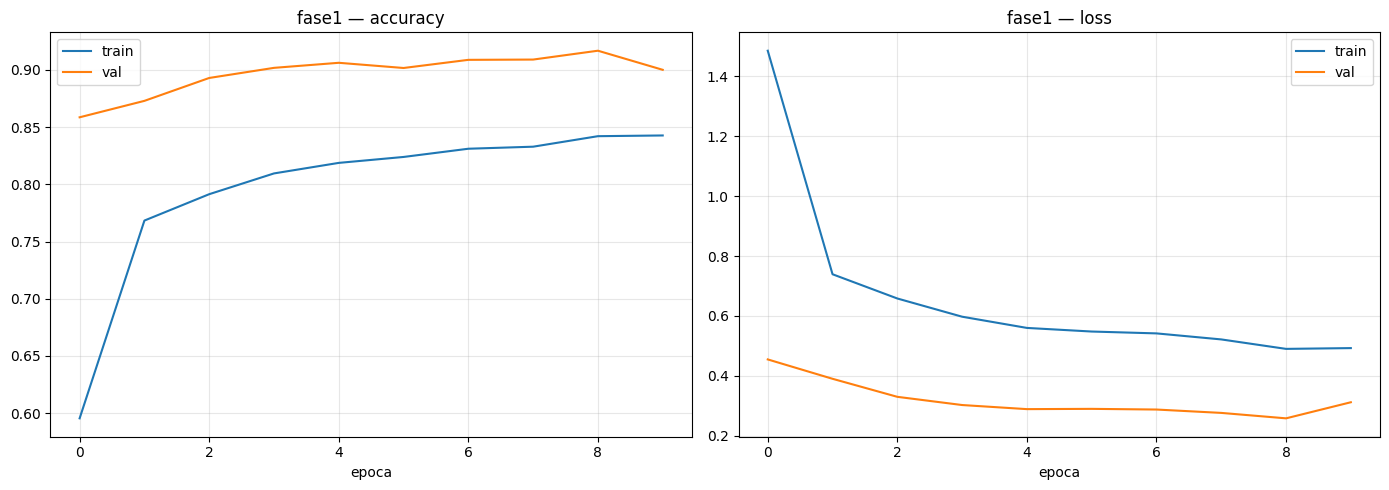

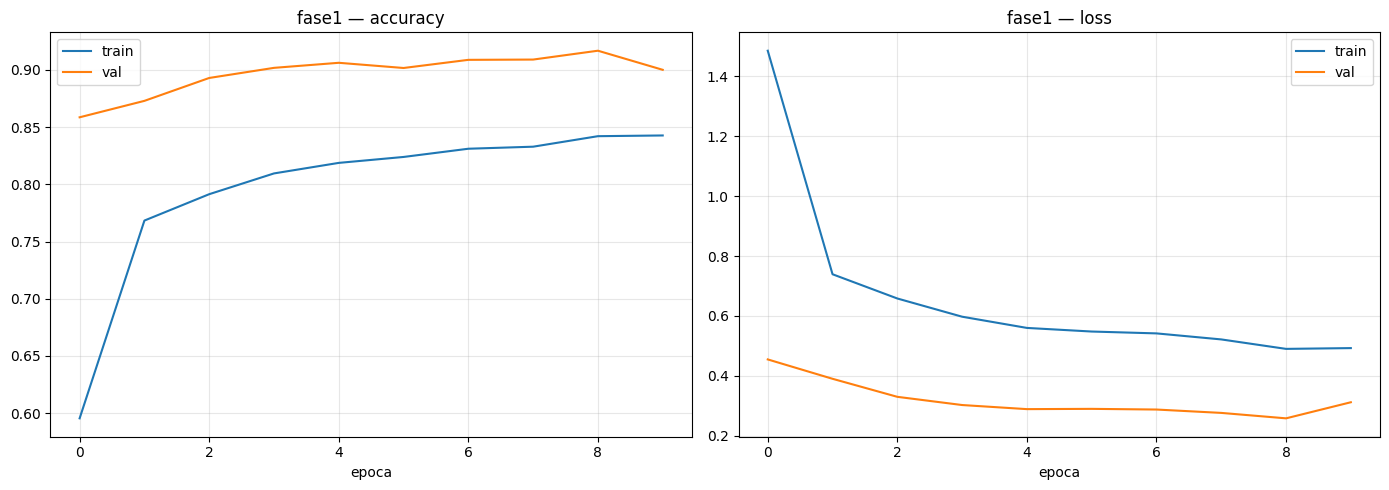

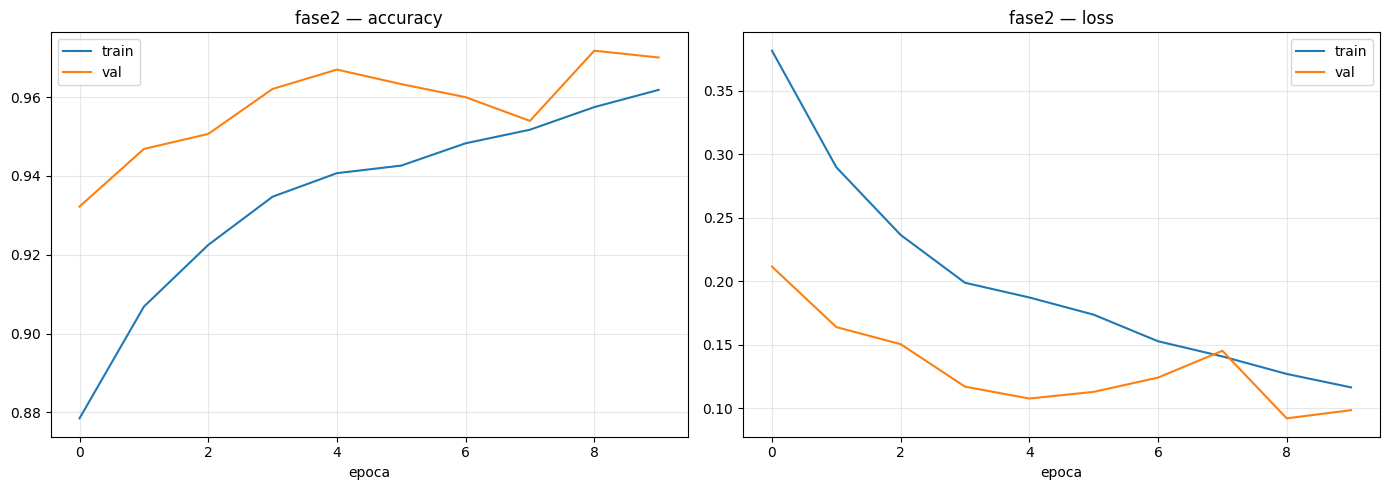

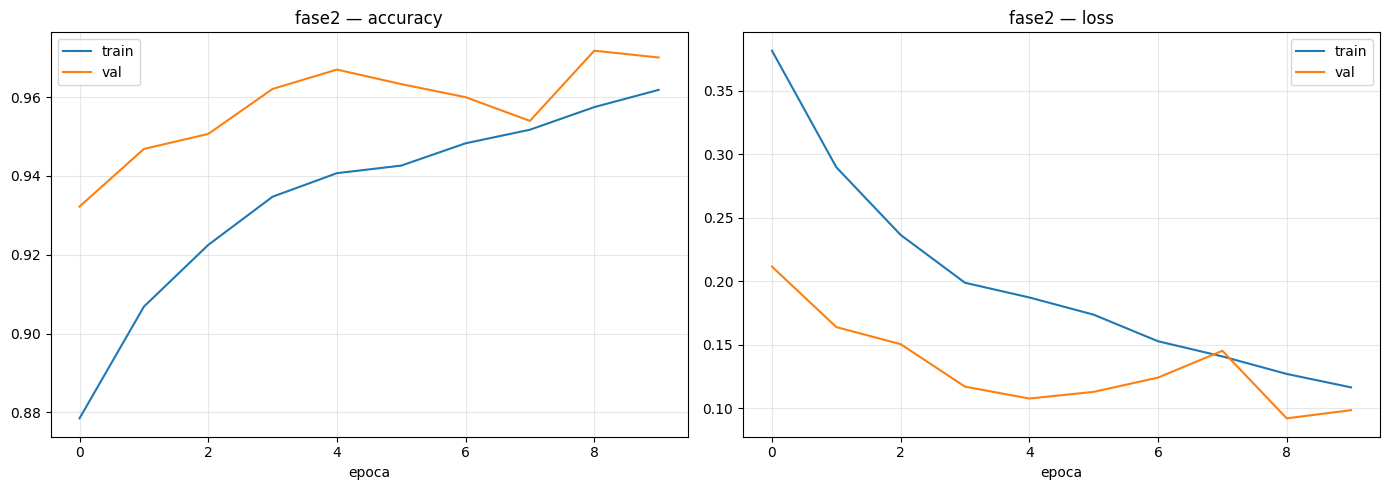

In [10]:
def plot_curvas(history, titulo):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'],     label='train')
    ax1.plot(history.history['val_accuracy'], label='val')
    ax1.set_title(f'{titulo} — accuracy')
    ax1.set_xlabel('epoca')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'],     label='train')
    ax2.plot(history.history['val_loss'], label='val')
    ax2.set_title(f'{titulo} — loss')
    ax2.set_xlabel('epoca')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{WORK_PATH}/vgg16_curvas_{titulo}.png', dpi=150)
    plt.show()

plot_curvas(history_fase1, 'fase1')
plot_curvas(history_fase2, 'fase2')

## Curva combinada fase 1 + fase 2

Uno los historiales de las dos fases para ver el entrenamiento completo en una sola grafica.

In [ ]:
acc_total  = history_fase1.history['accuracy']     + history_fase2.history['accuracy']
val_total  = history_fase1.history['val_accuracy'] + history_fase2.history['val_accuracy']
loss_total = history_fase1.history['loss']         + history_fase2.history['loss']
vloss_total= history_fase1.history['val_loss']     + history_fase2.history['val_loss']

# linea vertical que marca donde termina la fase 1
corte = len(history_fase1.history['loss'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(acc_total,  label='train')
ax1.plot(val_total,  label='val')
ax1.axvline(corte, color='gray', linestyle='--', alpha=0.7, label='inicio fine-tuning')
ax1.set_title('accuracy completo')
ax1.set_xlabel('epoca')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(loss_total,  label='train')
ax2.plot(vloss_total, label='val')
ax2.axvline(corte, color='gray', linestyle='--', alpha=0.7, label='inicio fine-tuning')
ax2.set_title('loss completo')
ax2.set_xlabel('epoca')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('VGG16 - trayectoria completa de entrenamiento', fontsize=12)
plt.tight_layout()
plt.savefig(f'{WORK_PATH}/vgg16_curvas_completo.png', dpi=150)
plt.show()

## Evaluacion en test

In [ ]:
best_model = tf.keras.models.load_model(
    f'{WORK_PATH}/vgg16_best.keras',
    custom_objects={'preprocess_input': tf.keras.applications.vgg16.preprocess_input}
)

# recorro el dataset una vez para que pred y labels queden alineados
y_pred_list, y_true_list = [], []
for images, labels in ds_test:
    preds = best_model(images, training=False)
    y_pred_list.extend(np.argmax(preds.numpy(), axis=1))
    y_true_list.extend(labels.numpy())

y_pred = np.array(y_pred_list)
y_true = np.array(y_true_list)

test_acc = np.mean(y_pred == y_true)
print(f'accuracy en test: {test_acc:.4f} ({test_acc*100:.2f}%)')
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

In [ ]:
cm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(22, 20))
sns.heatmap(cm, annot=False, cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('matriz de confusion normalizada — VGG16', fontsize=13)
plt.xlabel('prediccion')
plt.ylabel('real')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(f'{WORK_PATH}/vgg16_confusion.png', dpi=150)
plt.show()

In [ ]:
with open(f'{WORK_PATH}/resultados_vgg16.json') as f:
    resultados_vgg16 = json.load(f)

print('resultados cargados desde Drive')
print(f'modelo:        {resultados_vgg16["modelo"]}')
print(f'test accuracy: {resultados_vgg16["test_acc"]:.4f} ({resultados_vgg16["test_acc"]*100:.2f}%)')
print(f'epocas fase 1: {resultados_vgg16["epochs_fase1"]}')
print(f'epocas fase 2: {resultados_vgg16["epochs_fase2"]}')